# 🏺 Tourasna — Sequence Translation (Stage 3)
## Seq2Seq Transformer: Gardiner Codes → English
**Dataset:** BBAW Egyptian Corpus (100K parallel sentences)  
**Model:** Custom Transformer (encoder-decoder)  
**Tokenizer:** SentencePiece BPE (8000 vocab)  
**Repo:** github.com/Tourasna/Tourasna

In [1]:
# ── Environment Setup ─────────────────────────────────
!pip install datasets sentencepiece deep-translator -q

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.1 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [2]:
# ── Load BBAW Dataset from HuggingFace ────────────────
from datasets import load_dataset

ds = load_dataset("phiwi/bbaw_egyptian")
print(f"Total rows: {len(ds['train'])}")
print(f"Columns: {ds['train'].column_names}")

# Filter rows with hieroglyphs
valid_rows = []
for row in ds['train']:
    h = row['hieroglyphs']
    t = row['translation']
    if h and len(h.strip()) > 0 and t and len(t.strip()) > 0:
        valid_rows.append({'hieroglyphs': h.strip(), 'translation': t.strip()})

print(f"Rows with hieroglyphs + translation: {len(valid_rows)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/9.75M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100736 [00:00<?, ? examples/s]

Total rows: 100736
Columns: ['transcription', 'translation', 'hieroglyphs']
Rows with hieroglyphs + translation: 35501


In [3]:
# ── Extract Gardiner Codes from hieroglyphs ───────────
import re

def extract_codes(hieroglyph_str):
    """
    Extract pure Gardiner codes, removing layout operators.
    Layout operators: - (horizontal), : (vertical), * (overlap)
    Annotations: [? *X *?], h/, */, \\
    """
    clean = re.sub(r'\[.*?\]', '', hieroglyph_str)
    clean = re.sub(r'[h\*]/|\\\\', '', clean)
    tokens = clean.split()
    codes = [t.strip('-:*') for t in tokens]
    codes = [c for c in codes if re.match(r'^[A-Z][a-z]?\d+[A-Za-z]?$', c)]
    return codes

# Test
sample = valid_rows[0]['hieroglyphs']
codes = extract_codes(sample)
print(f"Raw: {sample[:80]}...")
print(f"Codes: {' '.join(codes[:15])}...")
print(f"Count: {len(codes)}")

Raw: D21 :Q3 :D36 F4 :D36 L2 -X1 :S19 S29 -U23 -T21 :X1 G17 -D21 :Z1 -R8 -U36 -S4 -F2...
Codes: D21 Q3 D36 F4 D36 L2 X1 S19 S29 U23 T21 X1 G17 D21 Z1...
Count: 51


In [4]:
# ── Separate English and German translations ──────────
import string

def is_english(text):
    ascii_ratio = sum(1 for c in text if c in string.printable) / max(len(text), 1)
    has_english = any(w in text.lower().split() for w in ['the', 'of', 'and', 'his', 'to', 'in', 'is', 'who', 'was'])
    has_german = any(w in text.lower().split() for w in ['der', 'die', 'das', 'und', 'des', 'dem', 'ein', 'ist', 'von'])
    return ascii_ratio > 0.85 and has_english and not has_german

english_rows = [r for r in valid_rows if is_english(r['translation'])]
german_rows = [r for r in valid_rows if not is_english(r['translation'])]

print(f"English rows: {len(english_rows)}")
print(f"German rows:  {len(german_rows)}")

English rows: 3338
German rows:  32163


In [5]:
# ── Translate German → English (batch mode) ───────────
from deep_translator import GoogleTranslator
from tqdm import tqdm
import time

translator_api = GoogleTranslator(source='de', target='en')
translated_rows = []
failed = 0
BATCH_SIZE = 10

for i in tqdm(range(0, len(german_rows), BATCH_SIZE), desc="Translating"):
    batch = german_rows[i:i+BATCH_SIZE]
    texts = [r['translation'][:300] for r in batch]
    try:
        joined = '\n'.join(texts)
        result = translator_api.translate(joined)
        translations = result.split('\n')
        for j, row in enumerate(batch):
            if j < len(translations) and translations[j].strip():
                translated_rows.append({
                    'hieroglyphs': row['hieroglyphs'],
                    'translation': translations[j].strip()
                })
            else:
                failed += 1
    except:
        failed += 1
        for row in batch:
            try:
                en = translator_api.translate(row['translation'][:300])
                translated_rows.append({
                    'hieroglyphs': row['hieroglyphs'],
                    'translation': en
                })
            except:
                failed += 1
        time.sleep(2)

all_english = english_rows + translated_rows
print(f"\nTranslated: {len(translated_rows)}")
print(f"Failed: {failed}")
print(f"Total English rows: {len(all_english)}")

Translating: 100%|██████████| 3217/3217 [42:26<00:00,  1.26it/s]


Translated: 32159
Failed: 4
Total English rows: 35497


In [6]:
# ── Prepare parallel pairs + split ────────────────────
import random, json

pairs = []
for row in all_english:
    codes = extract_codes(row['hieroglyphs'])
    translation = row['translation'].strip()
    if len(codes) >= 2 and len(translation) >= 3:
        pairs.append({'source': ' '.join(codes), 'target': translation})

random.seed(42)
random.shuffle(pairs)

train_size = int(len(pairs) * 0.85)
val_size = int(len(pairs) * 0.10)
train_pairs = pairs[:train_size]
val_pairs = pairs[train_size:train_size+val_size]
test_pairs = pairs[train_size+val_size:]

print(f"Valid pairs: {len(pairs)}")
print(f"Train: {len(train_pairs)}")
print(f"Val:   {len(val_pairs)}")
print(f"Test:  {len(test_pairs)}")

Valid pairs: 34278
Train: 29136
Val:   3427
Test:  1715


In [7]:
# ── Save pairs to Google Drive IMMEDIATELY ────────────
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = '/content/drive/MyDrive/Tourasna/hieroglyphics/translator'
os.makedirs(save_dir, exist_ok=True)

for name, data in [('train', train_pairs), ('val', val_pairs), ('test', test_pairs)]:
    with open(f'{save_dir}/{name}_pairs.json', 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False)

print(f"✅ Data pairs saved to: {save_dir}")
for f_name in os.listdir(save_dir):
    size = os.path.getsize(f'{save_dir}/{f_name}')
    print(f"   ├── {f_name} ({size/1024:.0f} KB)")

Mounted at /content/drive
✅ Data pairs saved to: /content/drive/MyDrive/Tourasna/hieroglyphics/translator
   ├── train_pairs.json (5181 KB)
   ├── val_pairs.json (604 KB)
   ├── test_pairs.json (307 KB)


## Tokenization
- **Source (Gardiner codes):** Word-level — each code is one token
- **Target (English):** SentencePiece BPE with 8000 vocab for 100% coverage

In [8]:
# ── Build Tokenizers ──────────────────────────────────
import sentencepiece as spm
from collections import Counter

# ── Target: BPE tokenizer ─────────────────────────────
with open('/content/tgt_train.txt', 'w', encoding='utf-8') as f:
    for p in train_pairs:
        f.write(p['target'].strip() + '\n')

spm.SentencePieceTrainer.train(
    input='/content/tgt_train.txt',
    model_prefix='/content/tgt_bpe',
    vocab_size=8000,
    model_type='bpe',
    pad_id=0, bos_id=1, eos_id=2, unk_id=3,
    pad_piece='<pad>', bos_piece='<sos>', eos_piece='<eos>', unk_piece='<unk>',
    character_coverage=0.9995,
    max_sentence_length=4096,
)

tgt_sp = spm.SentencePieceProcessor()
tgt_sp.load('/content/tgt_bpe.model')

# ── Source: word-level tokenizer ──────────────────────
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = '<pad>', '<sos>', '<eos>', '<unk>'

src_counter = Counter()
for p in train_pairs:
    src_counter.update(p['source'].split())

src_vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + \
            [tok for tok, cnt in src_counter.most_common() if cnt >= 2]
src_token2idx = {tok: i for i, tok in enumerate(src_vocab)}

print(f"Source vocab (Gardiner codes): {len(src_vocab)}")
print(f"Target vocab (BPE): {tgt_sp.get_piece_size()}")

# ── Save tokenizers to Drive ─────────────────────────
import shutil
shutil.copy('/content/tgt_bpe.model', f'{save_dir}/tgt_bpe.model')
shutil.copy('/content/tgt_bpe.vocab', f'{save_dir}/tgt_bpe.vocab')

with open(f'{save_dir}/src_vocab.json', 'w') as f:
    json.dump({'src_token2idx': src_token2idx, 'src_vocab': src_vocab}, f)

print("✅ Tokenizers saved to Drive")

Source vocab (Gardiner codes): 1333
Target vocab (BPE): 8000
✅ Tokenizers saved to Drive


In [9]:
# ── PyTorch Dataset & DataLoaders ─────────────────────
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_token2idx, tgt_sp, max_src=200, max_tgt=150):
        self.pairs = pairs
        self.src_token2idx = src_token2idx
        self.tgt_sp = tgt_sp
        self.max_src = max_src
        self.max_tgt = max_tgt
        self.unk_id = src_token2idx['<unk>']

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        src_tokens = pair['source'].split()[:self.max_src]
        src_ids = [self.src_token2idx.get(t, self.unk_id) for t in src_tokens]
        tgt_ids = self.tgt_sp.encode(pair['target'])[:self.max_tgt]
        tgt_ids = [1] + tgt_ids + [2]  # <sos> + content + <eos>
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=0)
    return src_padded, tgt_padded

train_loader = DataLoader(
    TranslationDataset(train_pairs, src_token2idx, tgt_sp),
    batch_size=64, shuffle=True, collate_fn=collate_fn, num_workers=2
)
val_loader = DataLoader(
    TranslationDataset(val_pairs, src_token2idx, tgt_sp),
    batch_size=64, shuffle=False, collate_fn=collate_fn, num_workers=2
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 456
Val batches:   54


In [10]:
# ── Transformer Model ─────────────────────────────────
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=300):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class HieroglyphTranslator(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, nhead=8,
                 num_encoder_layers=4, num_decoder_layers=4, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, dropout, max_len=300)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True
        )
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt):
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(src.device)
        src_padding_mask = (src == 0)
        tgt_padding_mask = (tgt == 0)
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_encoder(self.tgt_embedding(tgt) * math.sqrt(self.d_model))
        output = self.transformer(
            src_emb, tgt_emb, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask
        )
        return self.output_proj(output)

# Initialize
model = HieroglyphTranslator(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=tgt_sp.get_piece_size(),
    d_model=256, nhead=8,
    num_encoder_layers=4, num_decoder_layers=4,
    dim_ff=1024, dropout=0.15
).to(device)

total = sum(p.numel() for p in model.parameters())
print(f"Model: HieroglyphTranslator")
print(f"  Params: {total:,}")
print(f"  Src vocab: {len(src_vocab)}")
print(f"  Tgt vocab: {tgt_sp.get_piece_size()}")

Model: HieroglyphTranslator
  Params: 11,819,072
  Src vocab: 1333
  Tgt vocab: 8000


In [11]:
# ── Training Loop (auto-save to Drive) ────────────────
import torch.optim as optim
import time

EPOCHS = 30
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-4, epochs=EPOCHS, steps_per_epoch=len(train_loader)
)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Time':>6}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    # Train
    model.train()
    total_loss, total_tokens = 0, 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt[:, :-1])
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * tgt[:, 1:].ne(0).sum().item()
        total_tokens += tgt[:, 1:].ne(0).sum().item()
    train_loss = total_loss / total_tokens

    # Validate
    model.eval()
    total_loss, total_tokens = 0, 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            logits = model(src, tgt[:, :-1])
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
            total_loss += loss.item() * tgt[:, 1:].ne(0).sum().item()
            total_tokens += tgt[:, 1:].ne(0).sum().item()
    val_loss = total_loss / total_tokens

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    elapsed = time.time() - start

    print(f"{epoch:5d} | {train_loss:10.4f} | {val_loss:10.4f} | {elapsed:5.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f'{save_dir}/best_translator.pth')
        print(f"        ↑ Saved to Drive! Val Loss: {val_loss:.4f}")

print(f"\n✅ Training complete! Best Val Loss: {best_val_loss:.4f}")

Epoch | Train Loss |   Val Loss |   Time
---------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


    1 |     7.7297 |     6.9530 |  83.3s
        ↑ Saved to Drive! Val Loss: 6.9530
    2 |     6.3906 |     6.1264 |  88.5s
        ↑ Saved to Drive! Val Loss: 6.1264
    3 |     5.8053 |     5.5940 |  88.1s
        ↑ Saved to Drive! Val Loss: 5.5940
    4 |     5.2981 |     5.1353 |  88.0s
        ↑ Saved to Drive! Val Loss: 5.1353
    5 |     4.8633 |     4.7959 |  88.2s
        ↑ Saved to Drive! Val Loss: 4.7959
    6 |     4.5143 |     4.5470 |  88.7s
        ↑ Saved to Drive! Val Loss: 4.5470
    7 |     4.2246 |     4.3500 |  88.9s
        ↑ Saved to Drive! Val Loss: 4.3500
    8 |     3.9780 |     4.1841 |  89.0s
        ↑ Saved to Drive! Val Loss: 4.1841
    9 |     3.7643 |     4.0202 |  89.1s
        ↑ Saved to Drive! Val Loss: 4.0202
   10 |     3.5752 |     3.9360 |  88.9s
        ↑ Saved to Drive! Val Loss: 3.9360
   11 |     3.4064 |     3.8063 |  88.6s
        ↑ Saved to Drive! Val Loss: 3.8063
   12 |     3.2549 |     3.7292 |  87.7s
        ↑ Saved to Drive! Val Loss:

## Evaluation & Translation Examples

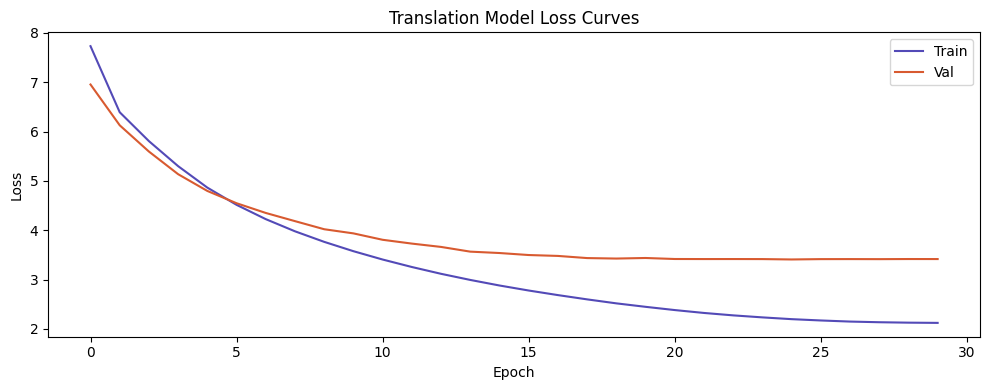

TRANSLATION EXAMPLES (Beam Search)

📜 Gardiner:  D21 D37 X1 S43 D46 X1 Y1 A2 Z3A N35 V28 Z7 M2 Z3A N12 Z...
✅ Reference: The matter of the Nebech plant (is) to be set (on) the first month of the season of Acheth (day) 17 
🤖 Predicted: Reignal year 25, month of the season of Shemu season, day 20, 5, day of the month of the season of t
----------------------------------------------------------------------

📜 Gardiner:  R8 D21 D58 Z2 I9 O34 X1 Z2 D2 Z1 N35 V31 A1 R4 G40 U36 ...
✅ Reference: [Any] God who owns his food: They say to you: "[--- welcome to] peace, O authority figure, useful to
🤖 Predicted: Let your Ka be satisfied with their offspring, so that you may see Amun, for you may see your Ka, wh
----------------------------------------------------------------------

📜 Gardiner:  D21 D36 G17 F51 O34...
✅ Reference: Werde in ihr „Fleisch“ (d.h. ihre Vagina) gegeben.
🤖 Predicted: Werde in ihr  ⁇ Fleisch“ (d.h. ihre Vagina) gegossen.
-----------------------------------------------------

In [12]:
# ── Loss Curves ───────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train', color='#534AB7')
ax.plot(history['val_loss'], label='Val', color='#D85A30')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Translation Model Loss Curves')
ax.legend()
plt.tight_layout()
plt.show()

# ── Beam Search Translation ───────────────────────────
import torch.nn.functional as F

model.load_state_dict(torch.load(f'{save_dir}/best_translator.pth', map_location=device))
model.eval()

def translate_beam(src_text, model, beam_size=5, max_len=100):
    model.eval()
    src_tokens = src_text.split()[:200]
    src_ids = [src_token2idx.get(t, src_token2idx['<unk>']) for t in src_tokens]
    src_tensor = torch.tensor([src_ids]).to(device)

    beams = [(0.0, [1])]
    completed = []

    for _ in range(max_len):
        candidates = []
        for score, tokens in beams:
            if tokens[-1] == 2:
                completed.append((score, tokens))
                continue
            tgt_tensor = torch.tensor([tokens]).to(device)
            with torch.no_grad():
                output = model(src_tensor, tgt_tensor)
            log_probs = F.log_softmax(output[0, -1], dim=-1)
            top_probs, top_ids = log_probs.topk(beam_size)
            for prob, idx in zip(top_probs, top_ids):
                token_id = idx.item()
                penalty = 0.0
                if len(tokens) >= 2 and token_id == tokens[-1]:
                    penalty = -2.0
                if len(tokens) >= 3 and token_id == tokens[-1] == tokens[-2]:
                    penalty = -5.0
                candidates.append((score + prob.item() + penalty, tokens + [token_id]))
        if not candidates:
            break
        candidates.sort(key=lambda x: x[0] / max(len(x[1]), 1), reverse=True)
        beams = candidates[:beam_size]

    all_results = completed + beams
    if not all_results:
        return ""
    all_results.sort(key=lambda x: x[0] / max(len(x[1]), 1), reverse=True)
    best_tokens = all_results[0][1]
    clean = [t for t in best_tokens if t not in [0, 1, 2]]
    return tgt_sp.decode(clean)

# ── Test examples ─────────────────────────────────────
import random
random.seed(42)
test_indices = random.sample(range(len(test_pairs)), 8)

print("=" * 70)
print("TRANSLATION EXAMPLES (Beam Search)")
print("=" * 70)

for idx in test_indices:
    pair = test_pairs[idx]
    prediction = translate_beam(pair['source'], model, beam_size=5)
    print(f"\n📜 Gardiner:  {pair['source'][:55]}...")
    print(f"✅ Reference: {pair['target'][:100]}")
    print(f"🤖 Predicted: {prediction[:100]}")
    print("-" * 70)

In [13]:
# ── Save final metadata ──────────────────────────────
metadata = {
    'model': 'HieroglyphTranslator (Transformer)',
    'd_model': 256, 'nhead': 8,
    'encoder_layers': 4, 'decoder_layers': 4,
    'src_vocab_size': len(src_vocab),
    'tgt_vocab_size': tgt_sp.get_piece_size(),
    'total_params': sum(p.numel() for p in model.parameters()),
    'best_val_loss': best_val_loss,
    'training_pairs': len(train_pairs),
    'epochs': EPOCHS,
    'dataset': 'BBAW Egyptian Corpus (35,497 parallel rows)',
    'tokenizer': 'SentencePiece BPE (8000)',
}
with open(f'{save_dir}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ All files on Drive:")
for f_name in os.listdir(save_dir):
    size = os.path.getsize(f'{save_dir}/{f_name}')
    print(f"   ├── {f_name} ({size/1024:.0f} KB)")

✅ All files on Drive:
   ├── train_pairs.json (5181 KB)
   ├── val_pairs.json (604 KB)
   ├── test_pairs.json (307 KB)
   ├── tgt_bpe.model (356 KB)
   ├── tgt_bpe.vocab (105 KB)
   ├── src_vocab.json (26 KB)
   ├── best_translator.pth (46518 KB)
   ├── metadata.json (0 KB)


## Greedy vs Beam Search Comparison
Greedy decoding picks the highest probability token each step — fast but causes repetition.  
Beam search keeps top-K candidates and adds repetition penalty — slower but better quality.

In [14]:
# ── Greedy Decode (for comparison) ────────────────────
def translate_greedy(src_text, model, max_len=100):
    model.eval()
    src_tokens = src_text.split()[:200]
    src_ids = [src_token2idx.get(t, src_token2idx['<unk>']) for t in src_tokens]
    src_tensor = torch.tensor([src_ids]).to(device)
    tgt_ids = [1]
    for _ in range(max_len):
        tgt_tensor = torch.tensor([tgt_ids]).to(device)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor)
        next_token = output[0, -1].argmax().item()
        if next_token == 2:
            break
        tgt_ids.append(next_token)
    return tgt_sp.decode(tgt_ids[1:])

# ── Compare ───────────────────────────────────────────
print("=" * 70)
print("GREEDY vs BEAM SEARCH")
print("=" * 70)

import random
random.seed(42)
test_indices = random.sample(range(len(test_pairs)), 6)

for idx in test_indices:
    pair = test_pairs[idx]
    greedy_out = translate_greedy(pair['source'], model)
    beam_out = translate_beam(pair['source'], model, beam_size=5)
    print(f"\n📜 Gardiner:  {pair['source'][:55]}...")
    print(f"✅ Reference: {pair['target'][:100]}")
    print(f"🔹 Greedy:    {greedy_out[:100]}")
    print(f"🔷 Beam:      {beam_out[:100]}")
    print("-" * 70)

GREEDY vs BEAM SEARCH

📜 Gardiner:  D21 D37 X1 S43 D46 X1 Y1 A2 Z3A N35 V28 Z7 M2 Z3A N12 Z...
✅ Reference: The matter of the Nebech plant (is) to be set (on) the first month of the season of Acheth (day) 17 
🔹 Greedy:    Reignal year 6, month of the season, day 20, 5, day 20, day 20, 5, day 25, month of the season, day 
🔷 Beam:      Reignal year 25, month of the season of Shemu season, day 20, 5, day of the month of the season of t
----------------------------------------------------------------------

📜 Gardiner:  R8 D21 D58 Z2 I9 O34 X1 Z2 D2 Z1 N35 V31 A1 R4 G40 U36 ...
✅ Reference: [Any] God who owns his food: They say to you: "[--- welcome to] peace, O authority figure, useful to
🔹 Greedy:    The gods who are in their mouths, their needs, their offspring, their offspring are satisfied with t
🔷 Beam:      Let your Ka be satisfied with their offspring, so that you may see Amun, for you may see your Ka, wh
----------------------------------------------------------------------

📜 Gar